# Exercise E3

Write a notebook to produce the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [3]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

## Exercise 1: South Pole

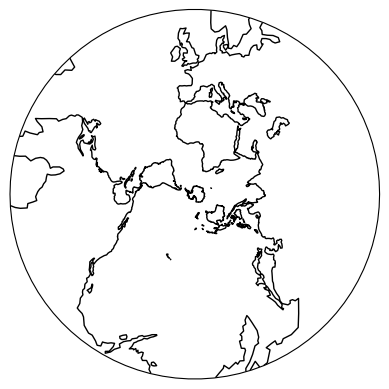

In [6]:
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()

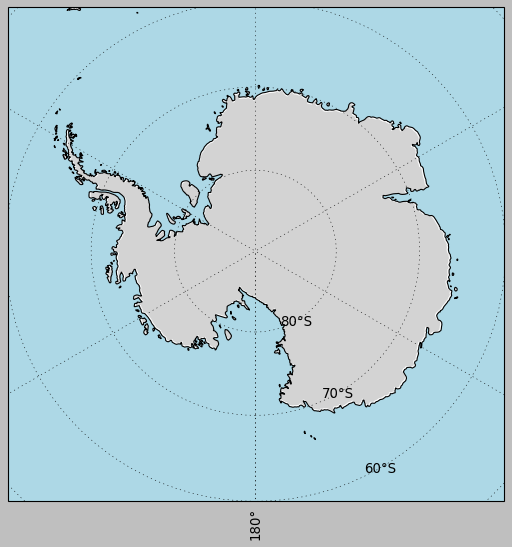

In [27]:
plt.figure(figsize=(8, 8))

ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Set extent: longitude range (-180 to 180), latitude range (-90 to -60)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Add coastlines
ax.coastlines()

# Add land and ocean shading
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Add gridlines for reference
gl = ax.gridlines(draw_labels=True)
gl.right_labels = False
gl.top_labels = False

plt.show()

### Exercise 2

C:\Users\AphileV\AppData\Local\anaconda3\envs\samos-core3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\AphileV\AppData\Local\anaconda3\envs\samos-core3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


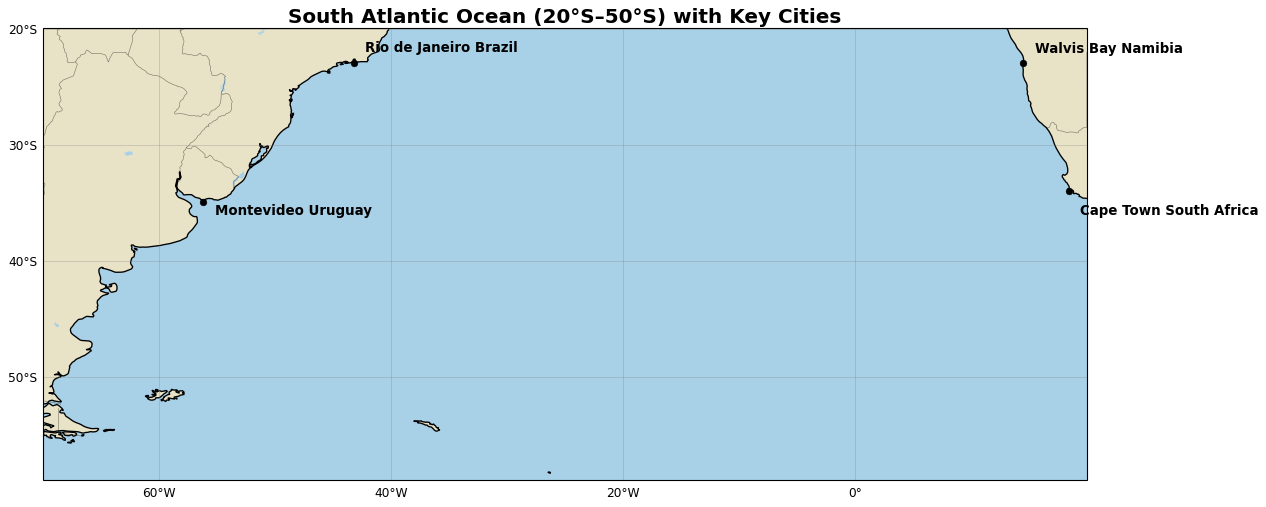

In [21]:

# Geolocator
geolocator = Nominatim(user_agent='educational')

# Extent
extent = [-70, 20, -50, -20]

# Places
places = ['Walvis Bay Namibia', 'Cape Town South Africa',
          'Rio de Janeiro Brazil', 'Montevideo Uruguay']

coords = []
for p in places:
    loc = geolocator.geocode(p)
    coords.append((p, loc.longitude, loc.latitude))

# BIGGER FIGURE
fig = plt.figure(figsize=(16, 9), facecolor='white')
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent)

# More realistic Earth-style features
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#a8d0e6')   
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#e8e2c6')   
ax.add_feature(cfeature.LAKES.with_scale('50m'), facecolor='#a8d0e6')

# Better coastlines
ax.coastlines(resolution='50m', linewidth=1.2, color='black')

# Subtle borders (optional but nice)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5, alpha=0.5)

# Solid gridlines (clean)
gl = ax.gridlines(draw_labels=True,
                  linestyle='-',
                  linewidth=0.5,
                  color='gray',
                  alpha=0.5)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Plot cities
for name, lon, lat in coords:
    ax.plot(lon, lat, 'o', color='black', markersize=6)

    # smarter spacing
    if "Cape Town" in name:
        offset = (1, -2)
    elif "Walvis Bay" in name:
        offset = (1, 1)
    elif "Rio" in name:
        offset = (1, 1)
    else:
        offset = (1, -1)

    ax.text(lon + offset[0], lat + offset[1],
            name,
            fontsize=12,
            fontweight='bold',
            fontfamily='DejaVu Sans')

# Title
plt.title("South Atlantic Ocean (20°S–50°S) with Key Cities",
          fontsize=18,
          weight='bold')

plt.tight_layout()
plt.show()


